### 机器学习完整的流水线
1. 收到需求,应当了解业务目标,以及要达成的目标是是什么.另外需要确认在目前阶段是否有现成的解决方法参考
2. 确认性能指标,也就是衡量一个算法预测结果与期望结果的误差(线性回归常用的平方根误差);检查假设输出内容是否与使用要求一致,比如想预测房价的是直接给出房价还是把价格转换为一个类别:高,低,合适
3. 下载数据,简单查看数据结构比如使用pandas的api,`describe`,`info`;或者可以通过matplotlib进行可视化查看
4. 划分测试集,一般取80%训练数据,20%为测试数据.以下有几个注意事项
    - 随机划分,每次训练都自动划分数据的话,随着次数的增加,训练就相当于看到了完整的数据,容易产生拟合.可以通过`np.random.seed`固定随机变量因子
    - 哈希值划分,解决增量部分数据,让测试集的数据更稳定.主要实现计算hash如果小于等于最大hash值的20%就进测试集
    - 分层划分,解决数据中含有分类的问题,让每个分类都都贡献信息,以免出现极端行情,某一分类在测试集出现的多训练出的模型出现过度拟合
5. 寻找相关性
    1. 皮尔逊相关系数(pearson corr)
        $p_{X,Y}=\frac{cov(X,V)}{std(X)std(Y)}$,通过Pandas的`df.corr(method=pearson)`计算;
    2. 斯皮尔曼等级相关(spearman rank corr)
       他是皮尔逊相关系数的变体,由于皮尔逊只能捕捉线性关系,对异常非常敏感,如果数据递增非线性或存在异常值就产生的误差比较大.而斯皮尔曼不计算具体数值相关,而是计算数据排序(把X,Y两个向量原始值从小到大排序,然后从中得到他们的排名比如[10,40,1]->[2,3,1]).通过Pandas的`df.corr(method=spearman)` 计算
       > 直觉理解,忽略掉具体的数值转换为排名后,通过数据(次序)增加/减少趋势来判断相关性
    3. 互信息
    > 信息论里概率,用来衡量一个变量包含另外一个变量多少信息.可以捕获任何非线性关系
    > scikit-learn `mutual_info_regression`,`mutual_info_classis`
    4. 根据以后的属性在创建(在特征属性之间做算术运算)
6. 清洗数据
    - 数据缺失处理
        1. 补0:
            适用场景缺失值代表某种行为未发生 - 比如30天内用户未购买商品记录
        2. 补中位数:
            适用场景数据呈现正态分布没有极端异常值,缺失比例通常不大的,这样不会改变特征总体数学期望和方差 - 比如传感器的采样数据
        3. 删除:
            适用场景当无法合理推测缺失值,且强行填入引噪音.根据数据量来进行不同的删除 - 比如数据多,缺失的行数较少直接删除缺失行;如果当列缺失值多直接删除该列
    - 特征值编码
        1. One-Hot Encoding
        2. Label
    - 特征值缩放
    > tips 清洗数据标准化,均值填充必须在训练集上,如果用了完整的数据求均值,模型就相当于偷看了测试数据,就会导致上线出现较大误差
7. 选择模型
    - 交叉验证误差
8. 模型微调


> 自动化探索工具
> 1.ydata-profiling  全面基础的分析工具,适用于前期摸底
> 2.Sweetviz 对比分析神器极,适合用于排查数据漂移（比如测试集里的数据分布是不是和训练集完全不一样，或者分层采样是否成功）。
> 3.AutoViz 自动决定图表类型的可视化专家,面对包含上百个特征的宽表,需要快速通过视觉寻找灵感时。

#### 下载数据与初步浏览

In [1]:
# 导入相关包
import requests
import tarfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
URL='https://github.com/ageron/data/raw/main/housing.tgz'
PATH='data/housing.tgz'

In [2]:
def load_data():
    if not os.path.exists(PATH):
        if not os.path.exists('data'):
            os.mkdir('data')
        rsp=requests.get(URL)
        if rsp.status_code ==200:
            with open(PATH,'wb') as fd:
                fd.write(rsp.content)
            with tarfile.open(PATH) as fd:
                fd.extractall('datasets')
    return pd.read_csv('datasets/housing/housing.csv')  

In [3]:
housing=load_data()

In [ ]:
# 查看数据表基本信息,类型,列,非空
housing.info()

In [ ]:
# 展示有非空行的列
housing.loc[housing.isna().any(axis=1)].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
182,-118.27,34.04,13.0,1784.0,NaN,2158.0,682.0,1.7038,118100.0,<1H OCEAN
327,-117.65,34.04,15.0,3393.0,NaN,2039.0,611.0,3.9336,151000.0,INLAND
366,-122.50,37.75,44.0,1819.0,NaN,1137.0,354.0,3.4919,271800.0,NEAR OCEAN
477,-117.99,34.14,30.0,2346.0,NaN,1988.0,474.0,2.5625,153000.0,INLAND
495,-114.59,34.83,41.0,812.0,NaN,375.0,158.0,1.7083,48500.0,INLAND


In [ ]:
# 展示数据的统计信息
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
housing['median_income'].value_counts()

In [ ]:
# 直方图 分箱
housing.assign(bins=pd.qcut(housing['median_income'],q=10)).groupby('bins',observed=True).count()['median_income']

(15.0001, 0.4999)

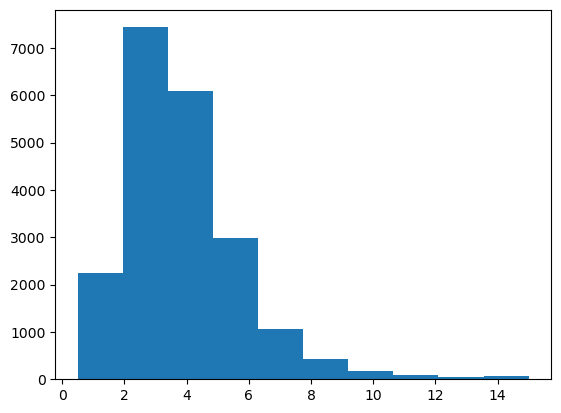

In [73]:
plt.hist(housing['median_income'],)
housing['median_income'].max(),housing['median_income'].min()

#### 测试集的处理

In [ ]:
def split_train_test(data,test_radio):
    np.random.seed(42)
    indices=np.random.permutation(len(data))
    idx=int(len(data)*test_radio)
    left=indices[:idx] 
    right=indices[idx:]
    return data.iloc[left],data.iloc[right]

test,train=split_train_test(housing,0.2)

In [ ]:
# 自带与上面功能一样
import sklearn.model_selection as skm
train,test=skm.train_test_split(housing,test_size=0.2,random_state=42)

In [ ]:
# 基于分层划分
housing['income_type']=pd.cut(housing['median_income'],bins=[0,1.5,3.0,4.5,6.0,np.inf],labels=[1,2,3,4,5])
# n_splits 后面迭代
split=skm.StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train,test in split.split(housing,housing['income_type']):
    train_set=housing.iloc[train]
    test_set=housing.iloc[test]

In [ ]:
import hashlib

# md5可以一个字符串对应唯一的十六进制数
# 加盐就是在字符串末尾拼接该字符,不加盐取模id桶号不会变.如果后面test_radio调节了原先桶的数据就会变.加了盐之后,只需要修改盐值,所有样本的哈希桶号会完全打乱重组
def hash_check(col,test_radio=0.2,salt='salt'):
    return int(hashlib.md5((str(col)).encode('utf-8')).hexdigest(),16)%10>10*test_radio

housing['id']=housing['longitude']*1000+housing['latitude']

def hash_split(data,col_name):
    idx=housing[col_name]
    bool=idx.apply(lambda id_:hash_check(id_))
    return data.loc[bool],data.loc[~bool]
    
train,test=hash_split(housing,'id')
len(train),len(test)


(14364, 6276)

#### 可视化
tips:当初线多个维度时,可以通过散点和色彩来可视化额外维度

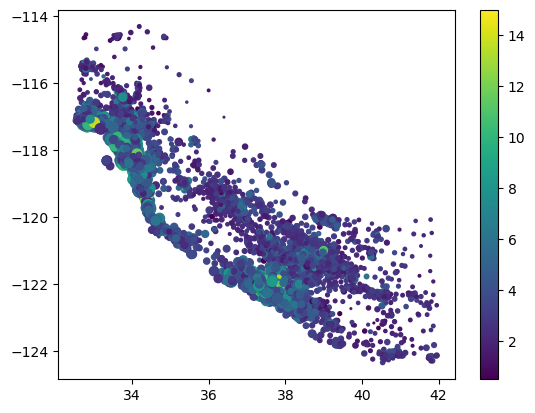

In [25]:
c=plt.scatter(housing['latitude'],housing['longitude'],
            c=housing['median_income'],s=housing['median_house_value']/10000,cmap='viridis'
            )
plt.colorbar(c)

In [121]:
int(hashlib.md5((str(10000)).encode('utf-8')).hexdigest(),16)%100

99

线性相关系数
$\sum_{1 \to n} \frac{(x1-u1)(x2-u2)}{std(x1)std(x2)}$

X1,X2分别是数据的一列属性,可以看成一组向量;(x1-u1)去中心化向量,$std(x1)=sqrt((x1-u1)^2)$去中心化向量的长度

由余弦定理定理 $cos(\theta)=\frac{\vec{x1}\vec{x2}}{\left\| \vec{x1} \right\|\left\| \vec{x2} \right\|}$,就可以向量之点积就是上面的式子分子运算,分母就是为两向量的长度

In [28]:
corr_matric=housing.drop(columns='ocean_proximity').corr()
corr_matric

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [ ]:
# 增加额外属性
housing.drop(columns='ocean_proximity')\
.assign(room_per_household=housing['total_rooms']/housing['households'],
    population_per_households=housing['population']/housing['households'])\
.corr()['population'].sort_values()


housing_median_age          -0.296244
latitude                    -0.108785
room_per_household          -0.072213
median_house_value          -0.024650
median_income                0.004834
population_per_households    0.069863
longitude                    0.099773
total_rooms                  0.857126
total_bedrooms               0.877747
households                   0.907222
population                   1.000000
Name: population, dtype: float64

In [5]:
import numpy as np
np.set_printoptions(suppress=True,precision=5)
# 这两个向量
median_income=housing['median_income']
median_income_mean=median_income.mean()

median_house_value=housing['median_house_value']
median_house_value_mean=median_house_value.mean()

p=np.dot(median_house_value-median_house_value_mean,median_income-median_income_mean)/ \
np.dot(np.linalg.norm(median_income-median_income_mean),np.linalg.norm(median_house_value-median_house_value_mean))

print(p)

0.6880752079585478


In [9]:

np.linalg.norm(median_income-median_income_mean),median_income.var()*len(median_income)

(272.9337068142285, 74496.41763791522)

In [48]:
median_income.var()

3.6093225599765124

In [51]:
np.sum((median_income-median_income_mean)**2)/len(median_income)

3.609147689697444

In [13]:
np.sqrt(np.sum((median_income-median_income_mean)**2))

272.9337068142285

#### 数据处理

In [11]:
# 补0
housing.fillna(0)
housing.isna().any(axis=0).all()

False

In [37]:
# 补中位数
nu_col=housing.columns[housing.isna().any()] # 找到缺失列
# 返回的是Series不是纯量
# fill_vals={housing[nu_col].median() for _ in nu_col.values}
fill_vals=housing[nu_col].median().to_dict()
housing.fillna(fill_vals)

housing.fillna(housing[nu_col].median())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
housing.drop(columns='total_bedrooms') # 删除列
housing.dropna(subset=['total_bedrooms']) # 删除行

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
from sklearn.impute import SimpleImputer
housing_num=housing.drop(columns='ocean_proximity')
impute=SimpleImputer(strategy='median')
X=impute.fit_transform(housing_num) # 返回处理好后的数据
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [ ]:
#文本处理 
# 字典编码与factorizex相同
from sklearn.preprocessing import OrdinalEncoder
housing_str=housing[['ocean_proximity']]
or_encode=OrdinalEncoder()
f=or_encode.fit(housing_str)
f.categories_,
np.unique(f.transform(housing_str))

array([0., 1., 2., 3., 4.])

In [ ]:
np.unique(pd.factorize(housing['ocean_proximity'])[0])

array([0, 1, 2, 3, 4])

In [ ]:
# one-hot
from sklearn.preprocessing import  OneHotEncoder
one_hot=OneHotEncoder()
one_hot=one_hot.fit(housing_str)
one_hot.transform(housing_str).toarray()
# 与类似pd.get_dummies

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [96]:
# 让自定义类进去到sk的生态
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
room_ix,bedroom_ix,population_ix,household=3,4,5,6
class CombineAttrAdd(BaseEstimator,TransformerMixin):
    
    def __init__(self,add=False):
        self.add=add

    def fit(self,X,y=None):
        return self

    def transform(self,X):
        print(type(X))
        if self.add:
            room_per_household=X[:,room_ix]/X[:,household]
            population_per_households=X[:,population_ix]/X[:,household]
            return np.c_[X,room_per_household,population_per_households]
        return np.c_[X]

pipe=Pipeline([('impute',impute),
               ('attradd',CombineAttrAdd(add=True)),
               ('stander',StandardScaler())])

print(len(housing_num.columns))
pd.DataFrame(pipe.fit_transform(housing_num))

9
<class 'numpy.ndarray'>


,0,1,2,3,4,5,6,7,8,9,10
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,2.129631,0.628559,-0.049597
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.314156,0.327041,-0.092512
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.258693,1.155620,-0.025843
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,1.165100,0.156966,-0.050329
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,1.172900,0.344711,-0.085616
...,...,...,...,...,...,...,...,...,...,...,...
20635,-0.758826,1.801647,-0.289187,-0.444985,-0.388283,-0.512592,-0.443449,-1.216128,-1.115804,-0.155023,-0.049110
20636,-0.818722,1.806329,-0.845393,-0.888704,-0.922403,-0.944405,-1.008420,-0.691593,-1.124470,0.276881,0.005021
20637,-0.823713,1.778237,-0.924851,-0.174995,-0.123608,-0.369537,-0.174042,-1.142593,-0.992746,-0.090318,-0.071735
20638,-0.873626,1.778237,-0.845393,-0.355600,-0.304827,-0.604429,-0.393753,-1.054583,-1.058608,-0.040211,-0.091225


In [107]:
# 指定 转换器能使用那些列
from sklearn.compose import ColumnTransformer
# list(housing_num) housing_num.columns
pipe_one_hot=ColumnTransformer([('pipe',pipe,list(housing_num))
                                ,('cat',OneHotEncoder(),['ocean_proximity'])])

pd.DataFrame(pipe_one_hot.fit_transform(housing))

<class 'numpy.ndarray'>


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,2.129631,0.628559,-0.049597,0.0,0.0,0.0,1.0,0.0
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.314156,0.327041,-0.092512,0.0,0.0,0.0,1.0,0.0
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.258693,1.155620,-0.025843,0.0,0.0,0.0,1.0,0.0
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,1.165100,0.156966,-0.050329,0.0,0.0,0.0,1.0,0.0
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,1.172900,0.344711,-0.085616,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-0.758826,1.801647,-0.289187,-0.444985,-0.388283,-0.512592,-0.443449,-1.216128,-1.115804,-0.155023,-0.049110,0.0,1.0,0.0,0.0,0.0
20636,-0.818722,1.806329,-0.845393,-0.888704,-0.922403,-0.944405,-1.008420,-0.691593,-1.124470,0.276881,0.005021,0.0,1.0,0.0,0.0,0.0
20637,-0.823713,1.778237,-0.924851,-0.174995,-0.123608,-0.369537,-0.174042,-1.142593,-0.992746,-0.090318,-0.071735,0.0,1.0,0.0,0.0,0.0
20638,-0.873626,1.778237,-0.845393,-0.355600,-0.304827,-0.604429,-0.393753,-1.054583,-1.058608,-0.040211,-0.091225,0.0,1.0,0.0,0.0,0.0
